<a href="https://colab.research.google.com/github/NickLarsonUVA/scratchpad/blob/main/Data%20wrangling%20and%20EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! git clone https://github.com/NickLarsonUVA/scratchpad

Cloning into 'scratchpad'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 42 (delta 6), reused 0 (delta 0), pack-reused 30 (from 1)
Receiving objects: 100% (42/42), 59.72 KiB | 1.81 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [2]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()



Download complete
Extracting data files...
Data extracted


In [3]:
import pandas as pd
df = pd.read_csv("/content/data/sharks.csv", encoding="latin1")

/tmp/ipython-input-3553316453.py:2: DtypeWarning: Columns (10,17,18,19,20,21,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/data/sharks.csv", encoding="latin1")


In [4]:
df.dtypes

,0
index,int64
Case Number,object
Date,object
Year,float64
Type,object
...,...
Unnamed: 251,float64
Unnamed: 252,float64
Unnamed: 253,float64
Unnamed: 254,float64


In [5]:
df.shape

(6462, 257)

In [6]:
df.tail()

,index,Case Number,Date,Year,Type,Country,Area,Location,Activity,Name,...,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254,Unnamed: 255
6457,6457,ND.0005,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6458,6458,ND.0004,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6459,6459,ND.0003,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6460,6460,ND.0002,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ÂºN, 79ÂºW",NaN,Jules Patterson,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6461,6461,ND.0001,1845-1853,0.0,Unprovoked,CEYLON (SRI LANKA),Eastern Province,"Below the English fort, Trincomalee",Swimming,male,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df['Area'].unique()

array(['Maui', 'Exumas', 'New South Wales', 'Southland', 'North Carolina',
       'Phang Nga Province', 'Queensland', 'Western Australia', nan,
       'Praslin', 'Central Province', 'Eastern Cape Province',
       'California', 'Hawaii', 'Florida', 'Guerrero', 'Moorea', 'Baja',
       'Saint-Gilles', 'Guam', 'Northern Territory', 'South Carolina',
       'Cayman Islands', 'Rhode Island', 'Chatham Islands', 'Quinta Roo',
       'Abaco Islands', 'Lucayan Archipelago', 'Georgia', 'Tasmania',
       'BÃ©lep Islands', 'Noumea', 'New Jersey', 'Liaoning Province',
       'Oregon', 'Fernando de Noronha', 'KwaZulu-Natal', 'South Island',
       'Sonora', 'North Island', 'Guizhou Province', 'New York', 'Texas',
       'San Andres and Providencia Archipelago', 'The Exuma Cays',
       'Colima', 'Pernambuco', 'Cornwall', 'Westerm Australia', 'Hua Hin',
       'Cocos Island', 'Alifu Alifu Atoll', 'Western Cape Province',
       'New Providence', 'Alagoas', 'Victoria', 'Boi Island, Victoria',
      

In [8]:
df['Area'].value_counts()

,count
Area,
Florida,1076
New South Wales,498
Queensland,325
Hawaii,312
California,294
...,...
"South Coast, East New Britain",1
Lau Province,1
Ysabel Island,1


<Axes: >

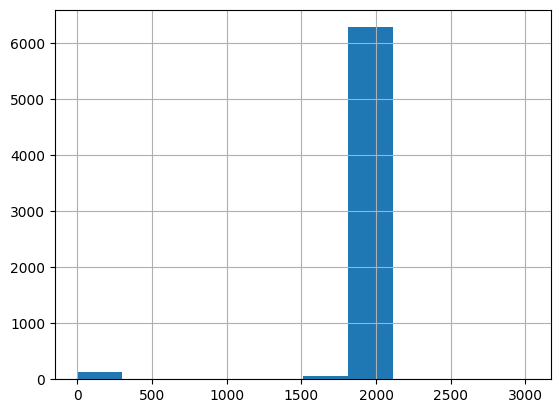

In [9]:
df['Year'].hist()

In [10]:
df['Year'].describe()

,Year
count,6459.000000
mean,1929.619446
std,278.316340
min,0.000000
25%,1943.000000
50%,1980.000000
75%,2006.000000
max,3019.000000


In [11]:
df['Year_na'] = df['Year'].isna()

In [12]:
df['Year_na'].describe() #?

,Year_na
count,6462
unique,2
top,False
freq,6459


In [13]:
df['Year'].unique()

array([2020., 2019., 3019., 2018., 2017.,   nan, 2016., 2015., 2014.,
       2013., 2012., 2011., 2010., 2009., 2008., 2007., 2006., 2005.,
       2004., 2003., 2002., 2001., 2000., 1999., 1998., 1997., 1996.,
       1995., 1984., 1994., 1993., 1992., 1991., 1990., 1989., 1969.,
       1988., 1987., 1986., 1985., 1983., 1982., 1981., 1980., 1979.,
       1978., 1977., 1976., 1975., 1974., 1973., 1972., 1971., 1970.,
       1968., 1967., 1966., 1965., 1964., 1963., 1962., 1961., 1960.,
       1959., 1958., 1957., 1956., 1955., 1954., 1953., 1952., 1951.,
       1950., 1949., 1948., 1848., 1947., 1946., 1945., 1944., 1943.,
       1942., 1941., 1940., 1939., 1938., 1937., 1936., 1935., 1934.,
       1933., 1932., 1931., 1930., 1929., 1928., 1927., 1926., 1925.,
       1924., 1923., 1922., 1921., 1920., 1919., 1918., 1917., 1916.,
       1915., 1914., 1913., 1912., 1911., 1910., 1909., 1908., 1907.,
       1906., 1905., 1904., 1903., 1902., 1901., 1900., 1899., 1898.,
       1897., 1896.,

In [14]:
# no commas, pretty clean, except for nan, in numeric values
#df['Year'].str.replace('.0','')  # already a numeric value so can't use this as it works for strings
pd.to_numeric(df['Year'],errors='coerce')

,Year
0,2020.0
1,2020.0
2,2020.0
3,2020.0
4,2020.0
...,...
6457,0.0
6458,0.0
6459,0.0
6460,0.0


In [15]:
df['Area'].str.replace(',','')

,Area
0,Maui
1,Exumas
2,New South Wales
3,Southland
4,North Carolina
...,...
6457,Western Australia
6458,Western Australia
6459,North Carolina
6460,NaN


New csv

In [18]:
df1 = pd.read_csv('/content/data/craigslist_cville_cars.csv')
df1.head()

,Unnamed: 0,title,price,year,link,brand,age
0,0,a sweet sedan avalon xle plus,24000,NaN,https://charlottesville.craigslist.org/cto/d/c...,missing,NaN
1,1,"1998 gmc sierra 1500 sl truck auto rwd <103,00...",6950,1998.0,https://charlottesville.craigslist.org/cto/d/l...,gmc,27.0
2,2,gmc sierra 3500hd 6.6 duramax diesel dually,26000,NaN,https://charlottesville.craigslist.org/cto/d/c...,gmc,NaN
3,3,2007 chrysler sebring,2900,2007.0,https://charlottesville.craigslist.org/cto/d/c...,missing,18.0
4,4,2012 nissan versa sl,3500,2012.0,https://charlottesville.craigslist.org/cto/d/c...,missing,13.0


In [20]:
df1['year'].describe()

,year
count,41.000000
mean,2000.878049
std,16.315936
min,1957.000000
25%,1994.000000
50%,2006.000000
75%,2012.000000
max,2019.000000


In [21]:
df1.shape

(46, 7)

In [23]:
df1['year_na'] = df1['year'].isna()
imp_value = df1['year'].median()
df1['year_imp'] = df1['year'].fillna(imp_value)

In [25]:
df1['brand'].value_counts()

,count
brand,
missing,14
honda,5
chevrolet,4
toyota,4
ford,3
chevy,3
bmw,3
jeep,2
gmc,2


In [28]:
df1.loc[ df1['brand'] == 'honda', : ] #locator function

,Unnamed: 0,title,price,year,link,brand,age,year_na,year_imp
23,23,2012 honda civic lx,5900,2012.0,https://charlottesville.craigslist.org/cto/d/h...,honda,13.0,False,2012.0
33,33,2006 honda pilot exl fwd,4700,2006.0,https://charlottesville.craigslist.org/cto/d/h...,honda,19.0,False,2006.0
41,41,2010 honda crv lx,6500,2010.0,https://charlottesville.craigslist.org/cto/d/h...,honda,15.0,False,2010.0
43,43,sold haters 1992 honda accord gas sipper sold,2300,1992.0,https://charlottesville.craigslist.org/cto/d/c...,honda,33.0,False,1992.0
45,45,2015 honda fit,8749,2015.0,https://charlottesville.craigslist.org/cto/d/c...,honda,10.0,False,2015.0
